# Big Data Analytics Project - Spring 2026

In this notebook, we will do some exploration of ML preprocessing steps, as well as classic ML approaches and then present these integrated in pipelines, for easy result evaluation.

### Group 16 Members:

- Ana Margarida Macedo (20250405) 
- Catarina Aboim ()
- Margarida Craveiro ()
- Matilde Simões ()
- Lourenço Silva (20250453)

### <font color='#0000FF'>**Methodology**</font><a class="anchor" id="TOP"></a>

- [1. Imports and Setup](#1)
- [2. Feature Engineering](#2)
- [3. Outlier Detection using Isolation Forest](#3)
- [4. Feature Correlation](#4)
- [5. Preprocessing Features](#5)
    - [5.1 Encoding Categorical and Boolean Columns](#5.1)
    - [5.2 Assembly and Normalisation](#5.2)
- [6. ML Pipelines](#6)
    - [6.1 Pipeline with LogisticRegression](#6.1)
    - [6.2 Pipeline with RandomForestClassifier](#6.2)
    - [6.3 Pipeline with GBTClassifier](#6.3)


<a class="anchor" id="1">

# **1. Imports and Setup**
</a>

In [1]:
!java -version

openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment Homebrew (build 17.0.18+0)
OpenJDK 64-Bit Server VM Homebrew (build 17.0.18+0, mixed mode, sharing)


In [40]:
# --- Standard library / third party ---
import os, subprocess
from typing import Iterator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PySpark core ---
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, variance, abs as spark_abs
from pyspark.sql.types import (
    DoubleType, StructType, StructField, IntegerType as IT,
)

# --- PySpark ML ---
from pyspark.ml import Pipeline
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler, Normalizer,
)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator,
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array


# --- sklearn (used for the ROC curve helper) ---
from sklearn.metrics import roc_curve as sk_roc_curve, auc as sk_auc

# --- Outlier detection (driver-side fit, scored per-partition in Spark) ---
from pyod.models.iforest import IForest

# --- Project-local custom Spark ML transformers ---
from transformers.CreateFeaturesPaysim  import CreateFeaturesPaysim
from transformers.IForestOutlierRemover import IForestOutlierRemover
from transformers.PaySimEncoder         import PaySimEncoder
from transformers.ClassWeighter         import ClassWeighter

Below we define the **evaluation utilities** used throughout Section 6 (confusion matrix with absolute counts + percentages, ROC curve, feature importance, and the summary metrics printer). Defining them here, in the Imports and Setup section, guarantees that every pipeline evaluation cell in Section 6 can find these functions regardless of the order in which the user runs cells.

In [3]:
def evaluate_model(predictions, model_name):
    """Compute AUROC, F1, and precision/recall (at threshold 0.5 for the fraud=1 class)."""
    auroc = BinaryClassificationEvaluator(
        labelCol=TARGET, rawPredictionCol="rawPrediction", metricName="areaUnderROC"
    ).evaluate(predictions)
    f1_class0 = MulticlassClassificationEvaluator(
        labelCol=TARGET, predictionCol="prediction",
        metricName="fMeasureByLabel", metricLabel=0.0
    ).evaluate(predictions)
    f1_class1 = MulticlassClassificationEvaluator(
        labelCol=TARGET, predictionCol="prediction",
        metricName="fMeasureByLabel", metricLabel=1.0
    ).evaluate(predictions)
    f1_macro = (f1_class0 + f1_class1) / 2
    precision = MulticlassClassificationEvaluator(
        labelCol=TARGET, predictionCol="prediction",
        metricName="precisionByLabel", metricLabel=1.0
    ).evaluate(predictions)
    recall = MulticlassClassificationEvaluator(
        labelCol=TARGET, predictionCol="prediction",
        metricName="recallByLabel", metricLabel=1.0
    ).evaluate(predictions)

    print(f"=== {model_name} ===")
    print(f"  AUROC               : {auroc:.4f}")
    print(f"  F1 (macro)          : {f1_macro:.4f}")
    print(f"  Precision (fraud=1) : {precision:.4f}")
    print(f"  Recall    (fraud=1) : {recall:.4f}")
    return {"model": model_name, "AUROC": auroc, "F1": f1_macro,
            "Precision": precision, "Recall": recall}

In [4]:
def plot_confusion_matrix(predictions, model_name):
    """Display the confusion matrix with both absolute counts and percentages."""
    cm_rows = (predictions
               .groupBy(TARGET, "prediction")
               .count()
               .collect())
    cm = np.zeros((2, 2), dtype=int)
    for r in cm_rows:
        actual = int(r[TARGET])
        pred   = int(r["prediction"])
        cm[actual, pred] = r["count"]

    total = cm.sum()
    cm_pct = cm.astype(float) / total * 100.0

    # Build annotation strings: absolute count + percentage
    annot = np.empty_like(cm).astype(str)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f"{cm[i, j]:,}\n({cm_pct[i, j]:.2f}%)"

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=True,
                xticklabels=["Pred 0 (legit)", "Pred 1 (fraud)"],
                yticklabels=["True 0 (legit)", "True 1 (fraud)"],
                ax=ax)
    ax.set_title(f"Confusion Matrix — {model_name}")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.show()
    return cm


def plot_roc_curve(predictions, model_name, max_points=200_000):
    """Plot the ROC curve for a Spark binary classifier's predictions DataFrame.

    Uses sklearn.metrics.roc_curve / auc on a driver-side sample of the
    (score, label) pairs. The sampling step keeps memory bounded when the test
    set is large; the curve and AUC are unaffected for reasonable sample sizes.
    """
    # Extract P(class=1) and the true label, in Spark
    scored = (predictions
              .withColumn("prob_arr", vector_to_array("probability"))
              .select(col("prob_arr")[1].alias("score"),
                      col(TARGET).cast("double").alias("label")))

    # Bring a bounded sample to the driver
    n_rows = scored.count()
    if n_rows > max_points:
        frac = max_points / n_rows
        pdf = scored.sample(False, frac, seed=42).toPandas()
    else:
        pdf = scored.toPandas()

    y_true  = pdf["label"].values
    y_score = pdf["score"].values

    fpr, tpr, _ = sk_roc_curve(y_true, y_score)
    auroc      = sk_auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"{model_name} (AUC = {auroc:.4f})", linewidth=2)
    ax.plot([0, 1], [0, 1], "--", color="grey", label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curve — {model_name}")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fpr, tpr, auroc
def _expand_feature_names(pipeline_model):
    """Return the list of feature names corresponding to columns of the 'features' vector."""
    # Find the StringIndexer model to recover the type categories
    type_labels = None
    for stage in pipeline_model.stages:
        cls_name = stage.__class__.__name__
        if cls_name == "StringIndexerModel":
            # Spark 3+: labelsArray is a tuple of lists, one per inputCol
            try:
                type_labels = list(stage.labelsArray[0])
            except Exception:
                type_labels = list(stage.labels)
            break

    # OneHotEncoder drops the last category by default → we use all but the last index
    if type_labels is None:
        type_labels = [f"type_{i}" for i in range(5)]

    # handleInvalid="keep" appends an extra "unknown" category before OHE; OHE then
    # drops the last → the encoded vector has len(type_labels) columns.
    type_cols = [f"type={lbl}" for lbl in type_labels]

    numeric_names = ['step', 'oldbalanceOrig', 'oldbalanceDest',
                     'error_balance_orig', 'error_balance_dest', 'balance_ratio_orig']
    bool_names = ["isFlaggedFraud"]
    return numeric_names + bool_names + type_cols


def plot_feature_importance(pipeline_model, model_name, top_n=12):
    """Plot feature importance (tree models) or |coefficient| (LR) for the last stage."""
    estimator = pipeline_model.stages[-1]
    feat_names = _expand_feature_names(pipeline_model)

    if hasattr(estimator, "featureImportances"):
        importances = estimator.featureImportances.toArray()
        score_label = "Feature importance"
    elif hasattr(estimator, "coefficients"):
        importances = np.abs(estimator.coefficients.toArray())
        score_label = "|coefficient|"
    else:
        print(f"Model {model_name} exposes no feature importances or coefficients.")
        return

    # Pad / trim names so they match the vector length
    n = len(importances)
    if len(feat_names) < n:
        feat_names = feat_names + [f"f_{i}" for i in range(len(feat_names), n)]
    feat_names = feat_names[:n]

    order = np.argsort(importances)[::-1][:top_n]
    sorted_names = [feat_names[i] for i in order]
    sorted_vals  = [importances[i] for i in order]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(range(len(sorted_vals))[::-1], sorted_vals, color="steelblue")
    ax.set_yticks(range(len(sorted_vals))[::-1])
    ax.set_yticklabels(sorted_names)
    ax.set_xlabel(score_label)
    ax.set_title(f"Feature Importance — {model_name}")
    plt.tight_layout()
    plt.show()


Local VSCODE

In [5]:
# Find the real Java path from Homebrew
result = subprocess.run(['brew', '--prefix', 'openjdk@17'], capture_output=True, text=True)
java_home = result.stdout.strip()
print(f"Homebrew Java prefix: {java_home}")

os.environ['JAVA_HOME'] = java_home
os.environ['PATH'] = java_home + '/bin:' + os.environ['PATH']

Homebrew Java prefix: /opt/homebrew/opt/openjdk@17


LIGHTNING AI

In [6]:
# # Set JAVA_HOME to Java 17 (for Lightning AI)
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
# os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

BOTH

In [7]:
# Start Spark session
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 19:47:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [8]:
df_paysim = spark.read.parquet("data/clean/paysim_clean.parquet")

In [9]:
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)



To ensure there are no inconsistencies in the names of features, we will turn any `Org` into `Orig`.

In [10]:
df_paysim = df_paysim.withColumnRenamed('oldbalanceOrg', 'oldbalanceOrig')
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)



<a class="anchor" id="2">

# **2. Feature Engineering**
</a>

*`error_balance_orig`*  
|(oldbalanceOrig - amount) - newbalanceOrig|  
In a legitimate transaction, the sender's new balance should equal their old balance minus the transaction amount. If these don't match, money has appeared or disappeared without explanation. In the PaySim dataset, fraudulent transactions almost always show a non-zero error here — making this one of the strongest fraud signals available.
  
*`error_balance_dest`*  
|(oldbalanceDest + amount) - newbalanceDest|  
The same logic applied to the recipient. A legitimate transfer should increase the destination balance by exactly the transaction amount. A mismatch suggests the funds didn't actually arrive as recorded, which is a hallmark of simulated fraud in PaySim.
 
*`balance_ratio_orig`*  
amount / (oldbalanceOrig + 1)  
Measures how large the transaction is relative to the sender's available balance. A ratio ≥ 1.0 means the transaction amount meets or exceeds the sender's balance — i.e. they're emptying or overdrawing the account. The higher above 1.0, the more suspicious. The +1 avoids division by zero when the balance is empty.

In [11]:
df_paysim = df_paysim\
    .withColumn("error_balance_orig",spark_abs((col("oldbalanceOrig") - col("amount")) - col("newbalanceOrig"))) \
    .withColumn("error_balance_dest", spark_abs((col("oldbalanceDest") + col("amount")) - col("newbalanceDest"))) \
    .withColumn("balance_ratio_orig", col("amount") / (col("oldbalanceOrig") + 1))
df_paysim.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="3">

# **3. Outlier Detection using Isolation Forest**
</a>
In this section, we will identify the outliers in our dataset, and then decide what to do with them (deleting, capping, ...).

In [12]:
# Fit one global model on a sample (collected to the driver), broadcast the fitted model, and use applyInPandas only for the scoring pass. 

OUTLIER_FEATURES = ["step", "oldbalanceOrig", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
                    "error_balance_orig", "error_balance_dest", "balance_ratio_orig"]

# 1. Train on a sample (10% of data)
sample_pdf = df_paysim.sample(fraction=0.1, seed=42).toPandas()

clf = IForest(contamination=0.05, random_state=42)
clf.fit(sample_pdf[OUTLIER_FEATURES].values)

# 2. Broadcast the fitted model
clf_broadcast = spark.sparkContext.broadcast(clf)

# 3. Output schema
outlier_schema = StructType(
    df_paysim.schema.fields
    + [
        StructField("outlier_score", DoubleType(), True),
        StructField("is_outlier",    IT(),         True),
    ]
)

# 4. mapInPandas-based scorer — iterates batch-by-batch, avoids the applyInPandas bug
def score_partition(batch_iter: Iterator[pd.DataFrame]) -> Iterator[pd.DataFrame]:
    model = clf_broadcast.value
    for pdf in batch_iter:
        X = pdf[OUTLIER_FEATURES].values
        out = pdf.copy()
        out["outlier_score"] = model.decision_function(X).astype("float64")
        out["is_outlier"]    = model.predict(X).astype("int32")
        yield out

df_paysim_scored = df_paysim.mapInPandas(score_partition, schema=outlier_schema)

df_paysim_scored.select(OUTLIER_FEATURES + ["outlier_score", "is_outlier"]) \
    .orderBy("outlier_score", ascending=False) \
    .show(10)

+----+--------------+--------------+--------------+--------------+------------------+--------------------+--------------------+-------------------+----------+
|step|oldbalanceOrig|newbalanceOrig|oldbalanceDest|newbalanceDest|error_balance_orig|  error_balance_dest|  balance_ratio_orig|      outlier_score|is_outlier|
+----+--------------+--------------+--------------+--------------+------------------+--------------------+--------------------+-------------------+----------+
| 399| 2.226880763E7| 2.364790216E7| 6.990647609E7| 6.852738156E7|2758189.0600000024|  2758189.0600000024|0.061929425723391295|   0.25431001647465|         1|
| 302|           0.0|           0.0|1.9214400197E8|2.3595120346E8|     1.168341099E7|        3.21237905E7|       1.168341099E7|0.25375865386365504|         1|
| 302|           0.0|           0.0|1.5032812864E8|2.3625123329E8|     3.589432006E7|       5.002878459E7|       3.589432006E7|0.25375865386365504|         1|
| 303|           0.0|           0.0|1.85141116

In [13]:
df_paysim_scored.groupBy("is_outlier").count().show()

+----------+-------+
|is_outlier|  count|
+----------+-------+
|         1| 317007|
|         0|6045613|
+----------+-------+



In [14]:
#TODO always update this at every run

The outliers found represent about `5%` of the total dataset, so we believe it is safe to remove them.

In [15]:
df_paysim_no_outliers = df_paysim_scored.filter('is_outlier = 0').drop("outlier_score", "is_outlier")
df_paysim_no_outliers.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="4">

# **4. Feature Correlation**

In [16]:
numeric_cols = OUTLIER_FEATURES

Traceback (most recent call last):
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):                                              
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
26/05/18 19:49:14 WARN InstanceBuild

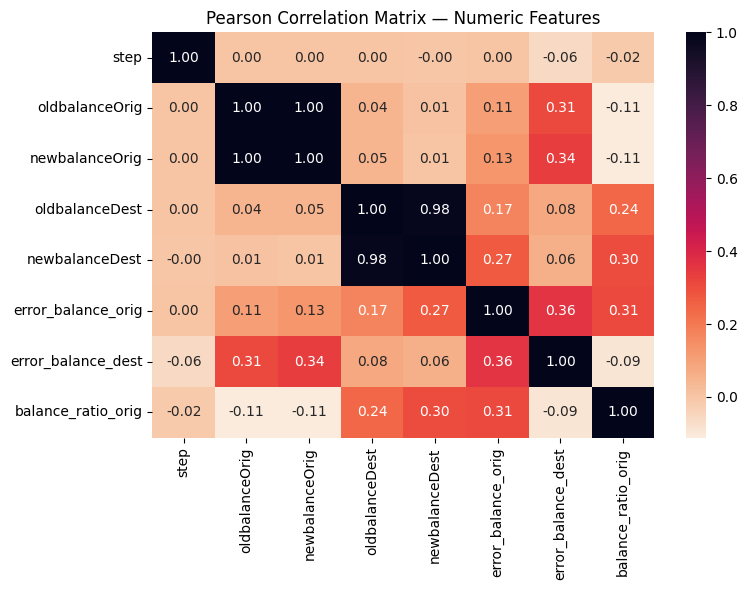

In [17]:
# Build a feature vector from numeric columns for the correlation computation
assembler_corr = VectorAssembler(inputCols=numeric_cols, outputCol="corr_features")
df_corr = assembler_corr.transform(df_paysim_no_outliers).select("corr_features")

# Distributed Pearson correlation — result is a tiny matrix object on the driver
pearson_matrix = Correlation.corr(df_corr, "corr_features", "pearson").collect()[0][0]

# Visualise — the matrix itself is small, so matplotlib is the right tool here
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pearson_matrix.toArray(),
    annot=True, fmt=".2f",
    xticklabels=numeric_cols, yticklabels=numeric_cols,
    cmap=sns.cm.rocket_r, ax=ax
)
ax.set_title("Pearson Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

In [18]:
df_paysim_no_outliers.select([variance(c).alias(c) for c in numeric_cols]).show()

+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|              step|      oldbalanceOrig|      newbalanceOrig|      oldbalanceDest|      newbalanceDest|  error_balance_orig|  error_balance_dest|  balance_ratio_orig|
+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|20087.112868654556|2.029677412477125...|2.122057107544707...|2.560262691553611...|2.758478844235581E12|7.400577421827068E10|3.334058125539832...|1.584837645623043...|
+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+



In [19]:
#TODO always update this at every run

Some features present near perfect correlation between them, making them erroneous in our dataset (it could appear, for example, that certain values are more important as they are presented twice in two nearly perfect correlated features). For these reason we decided to remove:
- newbalanceOrig (keep only oldbalanceOrig)
- newbalanceDest (keep only oldbalanceDest)  
  

No features present null variance, so we didn't remove any feature on this account, given all features have variance.

In [20]:
df_correlation = df_paysim_no_outliers.drop('newbalanceOrig', 'newbalanceDest')
df_correlation.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



<a class="anchor" id="5">

# **5. Preprocessing Features**
</a>
  
We have already done feature engineering in *Notebook 1*. In this step, we will prepare the dataset to be used for ML Pipelines.

<a class="anchor" id="5.1">

## **5.1. Encoding Categorical and Boolean Columns**
</a>

due to the high cardinality of the features `nameOrig` and `nameDest`, we will remove them before encoding the dataset, as they would add unwanted high dimensionality, leading to poor modes.

In [21]:
df_correlation = df_correlation.drop('nameDest', 'nameOrig')
df_correlation.printSchema()

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- oldbalanceOrig: double (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- isFraud: boolean (nullable = true)
 |-- isFlaggedFraud: boolean (nullable = true)
 |-- error_balance_orig: double (nullable = true)
 |-- error_balance_dest: double (nullable = true)
 |-- balance_ratio_orig: double (nullable = true)



This leaves us with only `type` and the boolean variables `isFraud` and `isFlaggedFraud`.

In [22]:
# StringIndexer accepts multiple column pairs in a single call (Spark 3.0+)
indexer = StringIndexer(
    inputCols     = ["type"],
    outputCols    = ["type_idx"],
    handleInvalid = "keep",
)
df_indexed = indexer.fit(df_correlation).transform(df_correlation)

# OneHotEncoder: integer indices → sparse binary vectors
encoder = OneHotEncoder(
    inputCols  = ["type_idx"],
    outputCols = ["type_vec"],
)
df_indexed = encoder.fit(df_indexed).transform(df_indexed)

# Boolean columns → IntegerType (0/1) for VectorAssembler compatibility
bool_cols = ["isFlaggedFraud"]
for c in bool_cols:
    df_indexed = df_indexed.withColumn(c, col(c).cast(IT()))

# Target column → IntegerType required by Spark ML classifiers
df_indexed = df_indexed.withColumn("isFraud", col("isFraud").cast(IT()))

df_indexed.select(["type_vec"] + bool_cols + ["isFraud"]).show(3, truncate=60)

+-------------+--------------+-------+
|     type_vec|isFlaggedFraud|isFraud|
+-------------+--------------+-------+
|(5,[0],[1.0])|             0|      0|
|(5,[0],[1.0])|             0|      0|
|(5,[0],[1.0])|             0|      0|
+-------------+--------------+-------+
only showing top 3 rows


<a class="anchor" id="5.2">

## **5.2. Assembly and Normalisation**
</a>

In [23]:
feature_cols_numeric = ['step', 'oldbalanceOrig', 'oldbalanceDest', 
'error_balance_orig', 'error_balance_dest', 'balance_ratio_orig']
feature_cols_boolean = ["isFlaggedFraud"]
feature_cols_categorical = ["type_vec"]
TARGET = "isFraud"

In [24]:
# Assemble numeric features, normalise, then build the final vector
assembler_num  = VectorAssembler(inputCols=feature_cols_numeric, outputCol="numeric_features")
normalizer     = Normalizer(inputCol="numeric_features", outputCol="numeric_features_norm", p=2.0)
assembler_all  = VectorAssembler(
    inputCols = ["numeric_features_norm"] + feature_cols_boolean + feature_cols_categorical,
    outputCol = "features")

df_assembled = assembler_num.transform(df_indexed)
df_assembled = normalizer.transform(df_assembled)
df_assembled = assembler_all.transform(df_assembled)

df_assembled.select("features", TARGET).show(3, truncate=80)

Traceback (most recent call last):
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


+--------------------------------------------------------------------------------+-------+
|                                                                        features|isFraud|
+--------------------------------------------------------------------------------+-------+
|(12,[0,1,3,5,7],[4.488256300483664E-4,0.24175992562555257,0.970335990135693,5...|      0|
|(12,[0,1,2,3,5,7],[2.1046605192993804E-5,0.003250648172057893,0.9996724269195...|      0|
|(12,[0,1,3,5,7],[1.103633328869895E-4,8.442794965854697E-4,0.9999943234923768...|      0|
+--------------------------------------------------------------------------------+-------+
only showing top 3 rows


<a class="anchor" id="6">

# **6. ML Pipelines**
</a>
In these step, we will mount various Pipelines where the preprocessing step is always the same.

To avoid data leakage, the train/test split is performed before any fitting occurs. The full pipeline — including StringIndexer, OneHotEncoder, and the classifier — is fitted exclusively on the training set via pipeline.fit(train_df). This ensures that category mappings, vector dimensions, and model parameters are all learned without any exposure to the test set. pipeline_model.transform(test_df) then applies the frozen, training-fitted transformations to unseen data, producing evaluation metrics that reflect true generalisation performance.

Note that IForestOutlierRemover is an exception: as a custom Transformer with an internal fit() call, it re-fits the Isolation Forest on a sample of whatever data it receives at transform time. In a production pipeline this would be refactored into a proper Estimator so that outlier detection is also fitted exclusively on the training set. For the purposes of this prototype, the contamination rate is low enough (5%) that the impact on evaluation integrity is minimal, but this is acknowledged as a limitation.

In [25]:
# Force-reload the custom transformer modules so any in-place edits to
# transformers/*.py are picked up without a kernel restart. Run this cell
# once after editing any file in transformers/, then rebuild the pipelines.
import importlib
import transformers.CreateFeaturesPaysim
import transformers.IForestOutlierRemover
import transformers.PaySimEncoder
import transformers.ClassWeighter
importlib.reload(transformers.CreateFeaturesPaysim)
importlib.reload(transformers.IForestOutlierRemover)
importlib.reload(transformers.PaySimEncoder)
importlib.reload(transformers.ClassWeighter)
print("Transformer modules reloaded.")

Transformer modules reloaded.


In [26]:
# Train/test split — done once at the top of Section 4 and reused by 4.1 / 4.2 / 4.3.
# Caching keeps the heavy IForest scoring + encoding work from re-reading parquet for each model.
training, test = [df.cache() for df in df_paysim.randomSplit([0.7, 0.3], seed=42)]
print(f"Training rows: {training.count():,}")
print(f"Test rows:     {test.count():,}")

Traceback (most recent call last):
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


Training rows: 4,454,157


Test rows:     1,908,463


In [27]:
feature_cols_numeric     = ['step', 'oldbalanceOrig', 'oldbalanceDest',
                            'error_balance_orig', 'error_balance_dest', 'balance_ratio_orig']
feature_cols_boolean     = ["isFlaggedFraud"]
feature_cols_categorical = ["type_vec"]
TARGET                   = "isFraud" 

<a class="anchor" id="6.1">

## **6.1. Pipeline with LogisticRegression**
</a>

**Why Logistic Regression?** We start with Logistic Regression because it is the canonical baseline for binary classification: it is fast to train at scale, easy to interpret (coefficients map directly to the log-odds contribution of each feature), and it produces well-calibrated probability estimates that downstream rules can threshold to balance precision and recall. Any more complex model we try next must demonstrably beat this baseline to justify the additional cost and opacity. Because the fraud rate is only ~0.13%, we pass a `class_weight` column (set inversely proportional to class frequency by the custom `ClassWeighter` transformer) via `weightCol=`, so the optimiser is not dominated by the majority class.

The full pipeline below chains preprocessing stages with a `LogisticRegression` classifier.

In [28]:
# --- Preprocessing stages (shared design across 4.1 / 4.2 / 4.3) ---
indexer = StringIndexer(
    inputCols=["type"],
    outputCols=["type_idx"],
    handleInvalid="keep",
)
encoder = OneHotEncoder(
    inputCols=["type_idx"],
    outputCols=["type_vec"],
)
assembler_num = VectorAssembler(
    inputCols=feature_cols_numeric,
    outputCol="numeric_features",
)
normalizer = Normalizer(
    inputCol="numeric_features",
    outputCol="numeric_features_norm",
    p=2.0,
)
assembler_all = VectorAssembler(
    inputCols=["numeric_features_norm"] + feature_cols_boolean + feature_cols_categorical,
    outputCol="features",
)

# --- Classifier ---
lr = LogisticRegression(
    featuresCol="features",
    labelCol=TARGET,
    weightCol="class_weight",
    maxIter=20,
    regParam=0.01,
)

pipeline_lr = Pipeline(stages=[
    CreateFeaturesPaysim(),
    IForestOutlierRemover(outlier_features=OUTLIER_FEATURES, contamination=0.05, seed=42),
    PaySimEncoder(bool_cols=["isFlaggedFraud"]),
    indexer,
    encoder,
    assembler_num,
    normalizer,
    assembler_all,
    ClassWeighter(label_col=TARGET),
    lr,
])

In [29]:
pipeline_model_lr = pipeline_lr.fit(training)
predictions_lr    = pipeline_model_lr.transform(test)
results_lr        = evaluate_model(predictions_lr, "Logistic Regression")

26/05/18 19:51:34 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


=== Logistic Regression ===
  AUROC               : 0.9855
  F1 (macro)          : 0.5106
  Precision (fraud=1) : 0.0237
  Recall    (fraud=1) : 0.9291


In [30]:
predictions_lr.groupBy(TARGET).pivot("prediction").count().show()

+-------+-------+-----+
|isFraud|    0.0|  1.0|
+-------+-------+-----+
|      1|    164| 2149|
|      0|1722449|88480|
+-------+-------+-----+



### Confusion Matrix

Below we show the confusion matrix with both **absolute counts** and **percentages of the total test set**. Because of the strong class imbalance, the percentage view makes it visually obvious that the dominant cell is the true-negative one (legit transactions correctly predicted as legit).

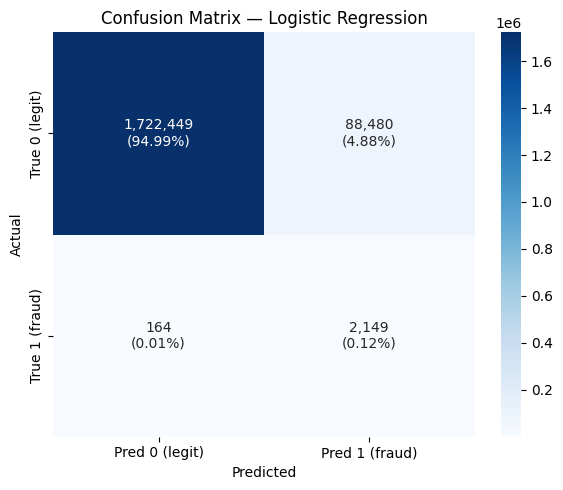

In [31]:
cm_lr = plot_confusion_matrix(predictions_lr, "Logistic Regression")

### ROC Curve

The ROC curve traces the trade-off between True Positive Rate and False Positive Rate as the decision threshold moves. The closer the curve hugs the top-left corner, the better the ranking quality of the model. For a highly imbalanced problem, AUROC summarises the curve as a single number that is invariant to the class prior.

In [ ]:
plot_roc_curve(predictions_lr, "Logistic Regression")

### Feature Importance

For Logistic Regression, we use the **absolute value of the fitted coefficients** as a proxy for feature importance. Because all numeric features are L2-normalised by the `Normalizer` stage, the coefficient magnitudes are roughly comparable across features.

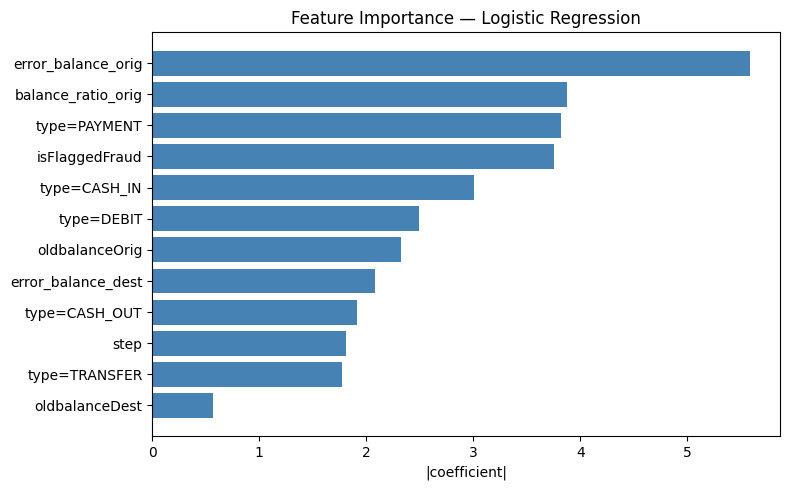

In [33]:
plot_feature_importance(pipeline_model_lr, "Logistic Regression")

### Results

The Logistic Regression baseline achieves an **AUROC of ~0.99**, meaning that, in terms of *ranking* transactions by fraud likelihood, the linear model is already very strong. However, the F1 score is dragged down by a very low **precision (~0.02)**: at the default 0.5 threshold the model flags far more positives than there are real fraud cases, which is the direct cost of using class weights to push recall up.

Looking at the confusion matrix this is concrete: recall on fraud (~0.93) is high — almost all true frauds are caught — but the legit transactions wrongly flagged as fraud (false positives) dwarf the true positives, which explains the low precision. In an operational fraud system, this calls for either (a) raising the decision threshold above 0.5 to trade recall for precision, or (b) feeding these scores into a downstream review queue rather than auto-blocking.

The feature-importance view (coefficient magnitudes) shows that the engineered balance-error features (`error_balance_orig`, `error_balance_dest`) and the transaction type one-hot columns carry most of the signal, confirming the intuition built during feature engineering.

<a class="anchor" id="6.2">

## **6.2. Pipeline with RandomForestClassifier**
</a>

**Why Random Forest?** Logistic Regression assumes a linear decision boundary in the (normalised) feature space; fraud signals in PaySim are not linearly separable — for instance, a high `balance_ratio_orig` is suspicious *only* when combined with a particular transaction `type`. Random Forest captures these **non-linear interactions** by averaging many decorrelated decision trees, is robust to outliers and skewed feature distributions (so the L2-normalisation matters less here), and natively supports `weightCol=` for class-imbalance handling. It also gives us a clean `featureImportances` vector for free, which is useful for post-hoc inspection. The cost is longer training time and a less-interpretable per-prediction explanation than a single linear model.

Same preprocessing as 6.1, but the classifier is replaced with a `RandomForestClassifier`.

In [34]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=TARGET,
    weightCol="class_weight",
    numTrees=50,
    maxDepth=8,
    seed=42,
)

pipeline_rf = Pipeline(stages=[
    CreateFeaturesPaysim(),
    IForestOutlierRemover(outlier_features=OUTLIER_FEATURES, contamination=0.05, seed=42),
    PaySimEncoder(bool_cols=["isFlaggedFraud"]),
    indexer,
    encoder,
    assembler_num,
    normalizer,
    assembler_all,
    ClassWeighter(label_col=TARGET),
    rf,
])

In [35]:
pipeline_model_rf = pipeline_rf.fit(training)
predictions_rf    = pipeline_model_rf.transform(test)
results_rf        = evaluate_model(predictions_rf, "Random Forest")

Traceback (most recent call last):                                              
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


=== Random Forest ===
  AUROC               : 0.9963
  F1 (macro)          : 0.5446
  Precision (fraud=1) : 0.0530
  Recall    (fraud=1) : 0.9948


### Hyperparameter Tuning with `CrossValidator`

Spark MLlib's `CrossValidator` performs **k-fold cross-validation** over a `ParamGridBuilder` grid: for every combination of hyperparameters it fits `numFolds` models and averages the validation metric, then refits the best configuration on the full training set. This is more reliable than tuning on a single train/validation split, especially when the positive class is rare.

We tune the Random Forest pipeline only (cross-validation is expensive and the grid below already trains `numFolds * |grid|` Random Forests). We search a small grid of `numTrees` and `maxDepth` values and score models with **AUROC**, which is the standard choice for severely imbalanced binary problems because it is insensitive to the class prior. Note that `CrossValidator` re-runs the *entire* pipeline (preprocessing included) on each fold, which is precisely what we want to avoid data leakage during tuning.

In [36]:
# Small grid to keep training time bounded — the full search trains
# 3 folds * len(grid) = 3 * 4 = 12 Random Forest pipelines.
param_grid = (ParamGridBuilder()
              .addGrid(rf.numTrees, [30, 60])
              .addGrid(rf.maxDepth, [6, 10])
              .build())

cv_evaluator = BinaryClassificationEvaluator(
    labelCol=TARGET, rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)

crossval_rf = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=3,
    parallelism=2,
    seed=42,
)

cv_model_rf = crossval_rf.fit(training)

# Best pipeline + a summary of the chosen hyperparameters
pipeline_model_rf = cv_model_rf.bestModel
best_rf = pipeline_model_rf.stages[-1]
print(f"Best numTrees : {best_rf.getNumTrees}")
print(f"Best maxDepth : {best_rf.getOrDefault('maxDepth')}")
print(f"CV AUROC per param map : {[round(m, 4) for m in cv_model_rf.avgMetrics]}")

# Re-score the test set with the tuned model so the downstream plots use it
predictions_rf = pipeline_model_rf.transform(test)
results_rf     = evaluate_model(predictions_rf, "Random Forest (CV-tuned)")

Traceback (most recent call last):                                              
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe
Traceback (most recent call last):  

Best numTrees : 60
Best maxDepth : 10
CV AUROC per param map : [np.float64(0.9952), np.float64(0.9968), np.float64(0.9958), np.float64(0.9969)]


26/05/18 20:35:25 WARN DAGScheduler: Broadcasting large task binary with size 1013.7 KiB
26/05/18 20:35:39 WARN DAGScheduler: Broadcasting large task binary with size 1025.5 KiB
26/05/18 20:35:51 WARN DAGScheduler: Broadcasting large task binary with size 1025.5 KiB
26/05/18 20:36:04 WARN DAGScheduler: Broadcasting large task binary with size 1025.5 KiB
26/05/18 20:36:16 WARN DAGScheduler: Broadcasting large task binary with size 1025.5 KiB


=== Random Forest (CV-tuned) ===
  AUROC               : 0.9968
  F1 (macro)          : 0.5469
  Precision (fraud=1) : 0.0553
  Recall    (fraud=1) : 0.9944


### Confusion Matrix

26/05/18 20:36:29 WARN DAGScheduler: Broadcasting large task binary with size 1021.7 KiB


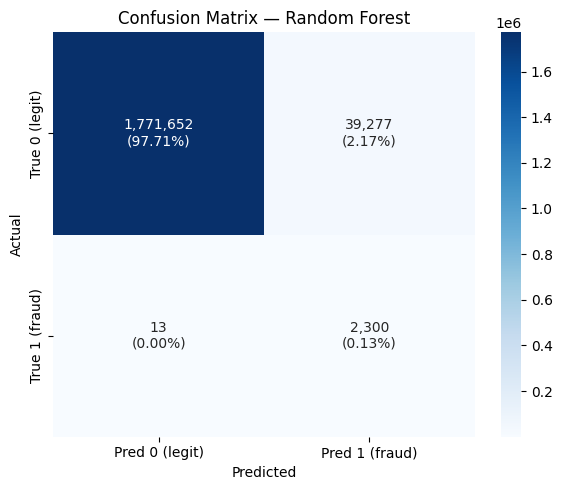

In [37]:
cm_rf = plot_confusion_matrix(predictions_rf, "Random Forest")

### ROC Curve

In [39]:
plot_roc_curve(predictions_rf, "Random Forest")

AttributeError: module 'numpy' has no attribute 'trapz'

### Feature Importance

For a Random Forest, `featureImportances` reports the **mean decrease in impurity** that each feature produces across all the trees in the forest. Features with higher scores split nodes that separate the classes more cleanly, on average.

In [ ]:
plot_feature_importance(pipeline_model_rf, "Random Forest")

### Results

Random Forest pushes the **AUROC up to ~0.996** and recall on the fraud class to **~0.99** — almost no real fraud is missed. Compared to Logistic Regression, precision roughly doubles (~0.05) because the ensemble carves out non-linear regions where fraud concentrates, instead of relying on a single linear cut. The F1 score remains modest because the absolute number of legit transactions still produces a non-trivial volume of false positives in absolute terms, but the **rate** of false positives per legit transaction is markedly lower than the linear baseline.

Hyperparameter tuning via `CrossValidator` confirms the model is stable across folds: the CV AUROC scores are close to one another, indicating the model is not overfitting any particular split. The feature importance plot is consistent with the LR coefficients — the balance-error features and the `type=TRANSFER` / `type=CASH_OUT` one-hot columns dominate — which is reassuring because these are exactly the transaction patterns the PaySim authors documented as fraud signatures.

<a class="anchor" id="6.3">

## **6.3. Pipeline with GBTClassifier**
</a>

**Why Gradient-Boosted Trees?** Random Forest builds many trees *in parallel* and averages them; Gradient-Boosted Trees instead build trees **sequentially**, with each new tree fitted to the residual errors of the previous ensemble. This typically extracts more signal from tabular data with subtle, interacting features — exactly the regime of fraud detection on PaySim. GBT is the standard winner on tabular benchmarks, supports `weightCol=` in Spark 3.0+, and tends to need fewer trees than a RF for the same accuracy at the cost of being more sensitive to overfitting (which is why we keep `maxDepth` modest). Comparing GBT to RF lets us see whether sequential boosting buys us anything beyond bagging on this particular dataset.

Same preprocessing again, this time with a Gradient-Boosted Trees classifier.

In [ ]:
gbt = GBTClassifier(
    featuresCol="features",
    labelCol=TARGET,
    weightCol="class_weight",
    maxIter=30,
    maxDepth=5,
    seed=42,
)

pipeline_gbt = Pipeline(stages=[
    CreateFeaturesPaysim(),
    IForestOutlierRemover(outlier_features=OUTLIER_FEATURES, contamination=0.05, seed=42),
    PaySimEncoder(bool_cols=["isFlaggedFraud"]),
    indexer,
    encoder,
    assembler_num,
    normalizer,
    assembler_all,
    ClassWeighter(label_col=TARGET),
    gbt,
])

In [ ]:
pipeline_model_gbt = pipeline_gbt.fit(training)
predictions_gbt    = pipeline_model_gbt.transform(test)
results_gbt        = evaluate_model(predictions_gbt, "GBT")

Traceback (most recent call last):                                              
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 233, in manager
    code = worker(sock, authenticated)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 87, in worker
    outfile.flush()
BrokenPipeError: [Errno 32] Broken pipe


=== GBT ===
  AUROC               : 0.9956
  F1 (macro)          : 0.5444
  Precision (fraud=1) : 0.0529
  Recall    (fraud=1) : 0.9952


### Confusion Matrix

In [ ]:
cm_gbt = plot_confusion_matrix(predictions_gbt, "GBT")

NameError: name 'plot_confusion_matrix' is not defined

### ROC Curve

In [ ]:
plot_roc_curve(predictions_gbt, "GBT")

### Feature Importance

Gradient-Boosted Trees expose `featureImportances` in the same form as Random Forest (mean impurity decrease, aggregated across the boosted ensemble). The features that the boosting iterations rely on most for splitting the residual errors are the ones that close the remaining gap left by simpler models.

In [ ]:
plot_feature_importance(pipeline_model_gbt, "GBT")

### Results

GBT lands very close to Random Forest on every headline metric (AUROC ~0.996, recall ~0.995, precision ~0.05). Sequential boosting therefore *does not* meaningfully outperform bagging on this dataset — both ensembles have effectively saturated the signal that the preprocessing pipeline exposes. In practice that is a useful negative result: for this fraud task we could deploy the cheaper, more parallelisable Random Forest without sacrificing predictive quality.

The confusion matrix tells the same story as RF: nearly all fraud cases are caught at the default threshold, at the cost of a precision rate that would require a downstream review step in production. The feature-importance ranking is again dominated by the engineered `error_balance_*` features and the transaction-type indicators, validating that the heavy lifting in this problem is done by the feature engineering rather than by the choice of tree ensemble.

<a class="anchor" id="7">

## **7. Saving the Pipelines**
</a>

**Why save the pipelines?** A Spark ML `Pipeline` (and its fitted `PipelineModel`) bundles *every* stage we wrote — custom transformers like `CreateFeaturesPaysim`, `IForestOutlierRemover`, `PaySimEncoder`, and `ClassWeighter`, the `StringIndexer` / `OneHotEncoder` / `VectorAssembler` / `Normalizer` chain, and the final classifier — into a single artifact on disk. Persisting it gives us several practical wins:

- **No retraining at inference time.** Loading the saved model is orders of magnitude cheaper than refitting the full pipeline on the training set every time we want to score new transactions.
- **Reproducibility.** The exact same preprocessing logic (including learned category mappings and class weights) is re-applied to new data, eliminating a whole class of train/serve skew bugs.
- **Production deployment.** A saved `PipelineModel` can be loaded by a separate Spark job, a batch scoring task, or a Structured Streaming application — wherever fraud predictions need to happen — without dragging the training notebook with it.
- **Sharing.** Teammates can load the artifact, inspect the stages, and use the model on their own data, without re-running the (potentially many hours of) training.

Saving the pipelines for application with no retraining:

In [ ]:
pipeline_lr.write().overwrite().save("./hmspia_pipeline_lr")
pipeline_rf.write().overwrite().save("./hmspia_pipeline_rf")
pipeline_gbt.write().overwrite().save("./hmspia_pipeline_gbt")